# Q5 Feature Stability Analysis (Batch1~3)
목표:
- Batch별 feature correlation 비교
- 공통 feature 찾기
- Regression용 feature 후보 선정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Correlation 계산

In [6]:
df1 = pd.read_csv("../results/batch1_features.csv")

df2 = pd.read_csv("../results/batch2_features.csv")

df3 = pd.read_csv("../results/batch3_features.csv")

In [8]:
corr1 = df1.select_dtypes(include=np.number).corr()['cycle_life']

corr2 = df2.select_dtypes(include=np.number).corr()['cycle_life']

corr3 = df3.select_dtypes(include=np.number).corr()['cycle_life']

## Feature stability table

In [9]:
corr_table = pd.concat([corr1,corr2,corr3],axis=1)
corr_table.columns=['Batch1','Batch2','Batch3']
corr_table

,Batch1,Batch2,Batch3
cycle_life,1.000000,1.000000,1.000000
IR_mean,0.176631,-0.352537,0.190233
QDischarge_mean,0.193393,-0.332111,0.217499
Tmax_mean,-0.403596,0.018960,-0.106455
Tavg_mean,-0.481775,0.424616,-0.021817
charge_time_mean,0.577037,0.087033,0.637495
IR_delta,0.307470,0.354646,-0.389579
QDischarge_delta,0.295098,-0.216027,0.252774
IR_delta_100_10,0.118457,0.093367,-0.381459
QDischarge_delta_100_10,0.549991,-0.187254,0.329881


## Stable feature 찾기

In [10]:
stable = corr_table[abs(corr_table).mean(axis=1)>0.2]
stable

,Batch1,Batch2,Batch3
cycle_life,1.000000,1.000000,1.000000
IR_mean,0.176631,-0.352537,0.190233
QDischarge_mean,0.193393,-0.332111,0.217499
Tavg_mean,-0.481775,0.424616,-0.021817
charge_time_mean,0.577037,0.087033,0.637495
IR_delta,0.307470,0.354646,-0.389579
QDischarge_delta,0.295098,-0.216027,0.252774
QDischarge_delta_100_10,0.549991,-0.187254,0.329881
IR_var,0.173550,-0.468169,0.196196
QDischarge_var,-0.100834,0.196352,-0.349841


## Heatmap 비교

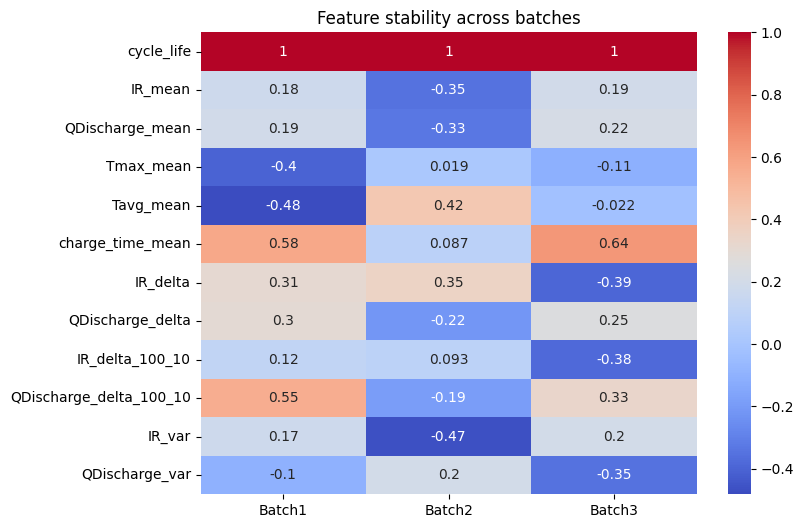

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_table,annot=True,cmap='coolwarm')
plt.title('Feature stability across batches')
plt.show()

## Feature importance ranking

In [12]:
corr_table['mean_corr']=abs(corr_table).mean(axis=1)
corr_table.sort_values('mean_corr',ascending=False)

,Batch1,Batch2,Batch3,mean_corr
cycle_life,1.000000,1.000000,1.000000,1.000000
charge_time_mean,0.577037,0.087033,0.637495,0.433855
QDischarge_delta_100_10,0.549991,-0.187254,0.329881,0.355709
IR_delta,0.307470,0.354646,-0.389579,0.350565
Tavg_mean,-0.481775,0.424616,-0.021817,0.309403
IR_var,0.173550,-0.468169,0.196196,0.279305
QDischarge_delta,0.295098,-0.216027,0.252774,0.254633
QDischarge_mean,0.193393,-0.332111,0.217499,0.247668
IR_mean,0.176631,-0.352537,0.190233,0.239800
QDischarge_var,-0.100834,0.196352,-0.349841,0.215676
